# PROC GPROJECT를 활용한 임상시험 기관 좌표 지도 투영

## 요약

임상운영팀은 다기관 3상 시험의 지리적 분포를 평면 지도에 표시해야 합니다. 이 노트북은
다섯 개의 U.S. 지역 허브를 중심으로 군집된 시험 기관의 합성 위도/경도 좌표를 생성한 뒤,
**PROC GPROJECT**를 사용해 세 가지 투영 방식(Albers 등적 투영, 사용자 지정 표준 위선과
지역 클리핑을 적용한 Lambert 정각 투영, 대륙부 U.S.를 중심으로 한 Gnomonic 투영)으로
구면 좌표를 평면 X/Y 값으로 변환하여 투영 방식과 클리핑이 기관 지도에 미치는 영향을
보여줍니다.

## 데이터 출처

| 데이터셋 | 행 수 | 주요 변수 | 설명 |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (허브 5개 x 기관 12개) | `site_id`($8 ID), `region`($12), `x`(경도, 도, 동쪽 양수), `y`(위도, 도), `enroll`(등록 피험자 수), `segment`(지도 세그먼트 ID) | `rand('normal')` 지터와 `rand('poisson')` 등록 건수를 사용하여 다섯 개의 U.S. 지역 허브(서부, 중서부, 북동부, 남부, 남동부) 주변에 흩뿌린 합성 3상 임상시험 기관 위치 |

# PROC GPROJECT를 활용한 임상시험 기관 좌표 투영

지리적으로 분산된 3상 시험을 운영하는 스폰서는 흔히 등록 인원 규모나 색상으로 표시된
모든 연구 기관을 하나의 지도에 담고 싶어합니다. 기관 위치는 **경도/위도 쌍**으로 주어지지만,
평면 지도에는 **평면 X/Y 좌표**가 필요합니다. `PROC GPROJECT`는 지도학적 투영을 적용하여
구면-직교좌표 변환을 수행함으로써 거리와 면적이 합리적으로 표현되게 합니다.

이 노트북에서는 다음을 수행합니다.

1. 다섯 개의 U.S. 지역 허브를 중심으로 군집된 합성 기관 좌표를 생성합니다.
2. 기본값인 **Albers 등적** 투영을 적용합니다.
3. 사용자 지정 표준 위선을 사용하고 대륙부 U.S.로 클리핑하는 **Lambert 정각** 투영을 적용합니다.
4. 국가의 지리적 중심에 중심을 둔 **Gnomonic** 투영을 적용하고, `ASIS`로 원본 좌표를 보존합니다.

모든 것이 자체 완결적입니다: 외부 파일 없음, 네트워크 없음.

## 1단계 — 합성 시험 기관 좌표 생성

재현성을 위해 `call streaminit`으로 난수 생성기 시드를 지정한 뒤, 다섯 개 지역 허브
도시 각각을 중심으로 12개의 기관을 배치합니다. 경도는 도 단위로 동쪽을 양수로 저장하고
(서반구는 음수), 위도도 도 단위로 저장합니다. 각 행에는 등록 건수와 `segment` 변수도
포함됩니다(GPROJECT는 투영 과정에서 좌표가 아닌 열을 그대로 보존합니다).

In [1]:
데이터 trial_sites;
    호출 streaminit(20260531);
    길이 site_id $8 region $12;
    /* 다섯 개의 U.S. 지역 허브 중심: 경도(동쪽 양수), 위도 */
    배열 clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    배열 clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    반복 hub = 1 까지 5;
        만약 hub = 1 이면 region = '서부';
        아니면 만약 hub = 2 이면 region = '중서부';
        아니면 만약 hub = 3 이면 region = '북동부';
        아니면 만약 hub = 4 이면 region = '남부';
        아니면 region = '남동부';
        반복 s = 1 까지 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* 경도(도) */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* 위도(도) */
            enroll  = round(rand('poisson', 60));           /* 등록 피험자 수 */
            segment = 1;
            출력;
        종료;
    종료;
    제거 hub s;
실행;

처리 인쇄 데이터=trial_sites(obs=10) 라벨;
    라벨 site_id="기관 ID" region="지역" x="경도" y="위도"
          enroll="등록 피험자 수" segment="세그먼트";
    제목 "합성 임상시험 기관 표본(투영 전 경도/위도)";
실행;

                                               합성 임상시험 기관 표본(투영 전 경도/위도)                                                

  Obs      기관 ID      지역               경도             위도              등록 피험자 수          세그먼트
    1  S101       서부      -121.6437232216  37.7677668495                    65             1
    2  S102       서부      -120.7384024716  37.5083287903                    61             1
    3  S103       서부      -121.5133780284  37.8633933883                    72             1
    4  S104       서부      -121.2086817368  38.7723343392                    68             1
    5  S105       서부      -121.0499572297   37.175813806                    54             1
    6  S106       서부      -124.0531899967   35.778231667                    72             1
    7  S107       서부      -120.9370181032  39.0576714397                    64             1
    8  S108       서부      -126.8495029747  36.6474680375                    55             1
    9  S109       서부       -123.475989897


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## 2단계 — 기본 Albers 등적 투영

**Albers** 등적 원추 투영은 GPROJECT의 기본값이며, *상대적 면적*을 보존하는 것이 중요한
국가 규모 지도(예: 지역 관할권의 크기 비교)에 적합한 선택입니다.

좌표가 **도** 단위로, **동쪽을 양수로 하는 경도**로 저장되어 있으므로 `DEGREE`와
`EASTLONG` 옵션을 지정합니다. `ID` 문은 각 단위를 고유하게 식별하는 변수를 지정하며,
투영된 평면 좌표는 `OUT=` 데이터셋의 `x`와 `y`에 다시 기록됩니다.

In [2]:
처리 GPROJECT 데이터=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
실행;

처리 인쇄 데이터=sites_albers(obs=10) 라벨;
    라벨 site_id="기관 ID" region="지역" x="투영 X(Albers)" y="투영 Y(Albers)"
          enroll="등록 피험자 수" segment="세그먼트";
    제목 "Albers 등적 투영 이후 시험 기관(평면 X/Y)";
실행;

                                               합성 임상시험 기관 표본(투영 전 경도/위도)                                                

                                             Albers 등적 투영 이후 시험 기관(평면 X/Y)                                              

  Obs      기관 ID      지역      투영 X(Albers)      투영 Y(Albers)              등록 피험자 수          세그먼트
    1  S101       서부          -0.346124731      0.0516986079                    65             1
    2  S102       서부         -0.3353644139      0.0440400181                    61             1
    3  S103       서부         -0.3439609675      0.0528501365                    72             1
    4  S104       서부         -0.3357513354       0.067213083                    68             1
    5  S105       서부         -0.3410170723      0.0394882801                    54             1
    6  S106       서부         -0.3879364507      0.0273340733                    72             1
    7  S107       서부         -0.3309127579      0.0711146305                 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## 3단계 — 사용자 지정 위선과 클리핑을 적용한 Lambert 정각 투영

**Lambert 정각** 원추 투영은 *형태와 국소 각도*를 보존하므로, 지도가 항법용이거나 방향성
있는 요소를 겹쳐 그릴 때 선호됩니다. 대륙부 U.S.의 경우 북위 33도와 45도 부근의 표준
위선이 관례적이므로 `PARALLEL1=`과 `PARALLEL2=`로 명시적으로 지정합니다.

또한 클리핑 옵션 `LATMIN=`, `LATMAX=`, `LONGMIN=`, `LONGMAX=`를 사용해 지도를 대륙부
U.S. 범위로 제한합니다. 이 위도/경도 상자를 벗어나는 기관은 투영 전에 제외되므로, 출력
관측치 수가 입력보다 적을 수 있습니다.

In [3]:
처리 GPROJECT 데이터=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
실행;

처리 인쇄 데이터=sites_lambert(obs=10) 라벨;
    라벨 site_id="기관 ID" region="지역" x="투영 X(Lambert)" y="투영 Y(Lambert)"
          enroll="등록 피험자 수" segment="세그먼트";
    제목 "Lambert 정각 투영 이후 시험 기관(대륙부 U.S.로 클리핑)";
실행;

                                             Albers 등적 투영 이후 시험 기관(평면 X/Y)                                              

                                         Lambert 정각 투영 이후 시험 기관(대륙부 U.S.로 클리핑)                                          

  Obs      기관 ID      지역      투영 X(Lambert)      투영 Y(Lambert)              등록 피험자 수          세그먼트
    1  S101       서부          -0.3473024124       0.0279382533                    65             1
    2  S102       서부          -0.3365626234       0.0201991247                    61             1
    3  S103       서부          -0.3451238364       0.0290365995                    72             1
    4  S104       서부          -0.3367881094       0.0430616123                    68             1
    5  S105       서부          -0.3422656751       0.0158037156                    54             1
    6  S106       서부          -0.3894389642       0.0046370991                    72             1
    7  S107       서부          -0.3319086764       0.0468276119 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## 4단계 — 국가 중심의 Gnomonic 투영, 원본 좌표 보존

**Gnomonic** 방위 투영은 모든 대원(great circle)을 직선으로 표현하므로, 기관 간 최단
경로를 파악하고 싶을 때(예: 모니터의 기관 방문 이동 경로 계획) 유용합니다. 왜곡은 투영
극에서 멀어질수록 커지므로, `POLELAT=39`와 `POLELONG=-98`로 극을 대륙부 U.S.의 지리적
중심에 둡니다.

`ASIS` 옵션은 GPROJECT가 투영된 값과 함께 원본의 투영되지 않은 좌표도 유지하도록
지시하므로, 출력 데이터셋은 평면 `X`/`Y`와 원본 `LONG`/`LAT`를 모두 담습니다 — 등록
지표를 어느 좌표 공간으로든 다시 조인할 때 유용합니다.

`PARMENTRY` 문은 투영 매개변수를 key=value 형태의 재정의 값으로 제공하는 대안적
방법으로 제시됩니다.

In [4]:
처리 GPROJECT 데이터=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
실행;

처리 인쇄 데이터=sites_gnomon(obs=10) 라벨;
    라벨 site_id="기관 ID" region="지역" x="투영 X(Gnomonic)" y="투영 Y(Gnomonic)"
          long="원본 경도" lat="원본 위도" enroll="등록 피험자 수" segment="세그먼트";
    제목 "Gnomonic 투영 이후 시험 기관(ASIS로 원본 LONG/LAT 보존)";
실행;

                                         Lambert 정각 투영 이후 시험 기관(대륙부 U.S.로 클리핑)                                          

                                       Gnomonic 투영 이후 시험 기관(ASIS로 원본 LONG/LAT 보존)                                       

  Obs      기관 ID      지역      투영 X(Gnomonic)      투영 Y(Gnomonic)              등록 피험자 수          세그먼트            원본 경도          원본 위도
    1  S101       서부           -0.3343477981        0.0213614461                    65             1  -121.6437232216  37.7677668495
    2  S102       서부           -0.3221611694        0.0134152735                    61             1  -120.7384024716  37.5083287903
    3  S103       서부           -0.3319480803        0.0225717184                    72             1  -121.5133780284  37.8633933883
    4  S104       서부           -0.3230855797        0.0375741352                    68             1  -121.2086817368  38.7723343392
    5  S105       서부           -0.3283677206        0.0086308769                    54     


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## 5단계 — 투영된 기관 지도 렌더링

투영을 하는 궁극적인 목적은 지도를 그리는 것입니다. Albers `OUT=` 데이터셋을 바로
**PROC SGPLOT**에 입력하여 평면 `X`/`Y`를 플로팅하고 각 마커를 `region`별로 색칠합니다.
투영이 상대적인 지리 관계를 보존했기 때문에, 다섯 개 허브 군집은 플롯의 예상된 모서리에
위치합니다 — 서부는 왼쪽, 북동부는 오른쪽 위, 남부와 남동부는 아래쪽 — 이는 요약에서
설명한 면적 충실 분포를 임상운영팀에게 제공합니다.

                                       Gnomonic 투영 이후 시험 기관(ASIS로 원본 LONG/LAT 보존)                                       




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


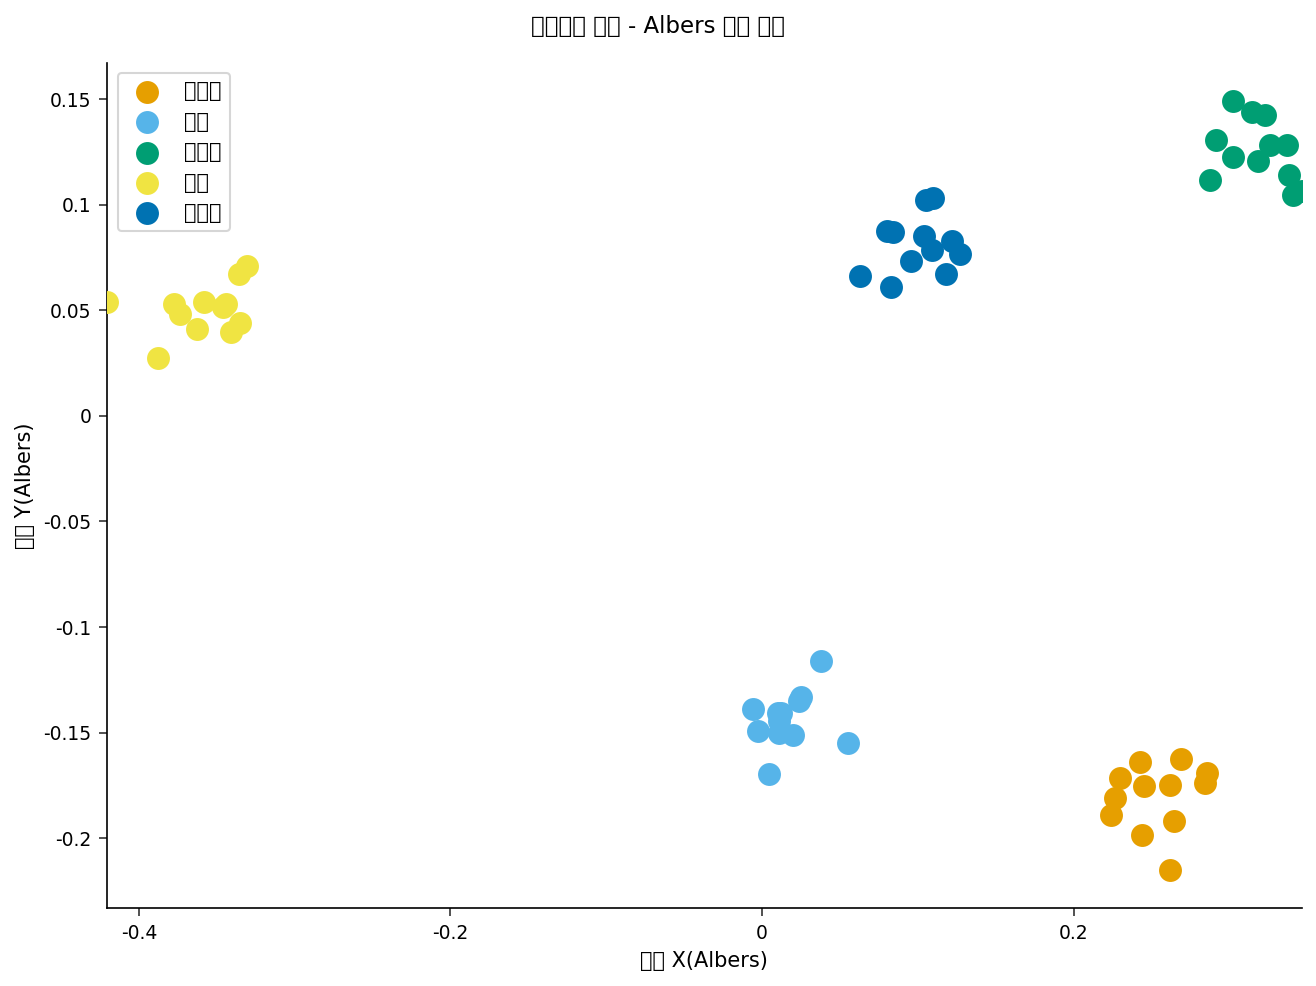

In [5]:
처리 SGPLOT 데이터=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS 라벨="투영 X(Albers)";
    YAXIS 라벨="투영 Y(Albers)";
    제목 "임상시험 기관 - Albers 투영 분포";
실행;

## 결과 해석

- **Albers(2단계)**는 상대적 면적을 보존하면서 60개 기관 전체를 평면 좌표로 변환했습니다 — 서부, 중서부, 북동부, 남부, 남동부 군집은 비례적인 공간 분포를 유지하므로, 면적 충실 등록 히트맵의 올바른 기반이 됩니다.
- **클리핑을 적용한 Lambert(3단계)**는 국소적 형태를 보존했고, `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX` 창을 적용함으로써 대륙부 U.S. 밖으로 흩어진 합성 기관을 제외했습니다 — 여기서 관측치 수는 60에서 58로 줄었으며, 그렇지 않았다면 지도를 왜곡시켰을 두 개의 그리드 밖 좌표가 투영 전에 제거된 것입니다.
- **`ASIS`를 적용한 Gnomonic(4단계)**은 국가 내부에 투영 중심을 두었고, `ASIS` 덕분에 투영된 `X`/`Y`와 원본 `LONG`/`LAT`를 모두 담은 데이터셋을 만들었습니다. 대원은 직선으로 나타나므로, 이 지도에서의 직선 거리는 기관 간 실제 최단 경로에 근사합니다.
- **렌더링된 분포(5단계)**는 투영이 제대로 작동했음을 확인시켜 줍니다: Albers `X`/`Y`를 지역별로 플로팅하면 다섯 개 허브 군집이 평면의 예상된 모서리에 위치하며, 이는 요약에서 약속한 면적 충실 기관 지도입니다.

**임상운영팀을 위한 핵심 시사점:** 투영은 겉치레가 아닙니다. 면적 충실 등록 밀도에는 **Albers**를, 지역 클리핑을 적용한 형태 충실 오버레이에는 **Lambert**를, 기관 간 이동 거리가 분석을 좌우할 때는 **Gnomonic**을 선택하십시오. 5단계에서 보듯이, 투영된 `OUT=` 데이터셋은 그대로 PROC SGPLOT(또는 PROC GMAP)에 입력되어 최종 기관 지도를 렌더링합니다.